# Parent Faults

This notebook demonstrates parent-fault-level view classes. Topics covered:

1. Creating a `ParentFault` facade
2. `ParentFaultData` — subsection attributes and `geometry` (oriented surface trace)
3. Constructing parent fault dimension tables from `ds.subsections`
4. `ParentFaultRuptures` — participating ruptures and cumulative MFDs
5. Direct instantiation of `ParentFaultData` and `ParentFaultRuptures`

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

from parserf import (
    FaultModel,
    FaultModelDataset,
    ParentFault,
    ParentFaultData,
    ParentFaultRuptures,
)

In [33]:
ds = FaultModelDataset(FaultModel.NSHMP_2023)

## 1. ParentFault Facade

`ParentFault` validates the name and exposes `.data` and `.ruptures`.

In [34]:
flt = ParentFault(ds, name="Compton")
print(flt)

ParentFault(fault_model=NSHMP_2023, name='Compton', parent_id=43)


## 2. ParentFaultData

In [35]:
print("Name:       ", flt.data.name)
print("Parent ID:  ", flt.data.parent_id)
print("Fault Model:", flt.data.fault_model.name)

Name:        Compton
Parent ID:   43
Fault Model: NSHMP_2023


### Child subsections

In [36]:
# Get the subsections for this parent fault
subs = flt.data.subsections
print(f"{len(subs)} subsections")
subs

5 subsections


,name,dip,dip_direction,upper_depth_km,lower_depth_km,aseismicity,length_km,width_km,area_km2,geometry
index,,,,,,,,,,
809,Compton (0),20.0,34.0,5.2,15.6,0.1,12.978331,30.407566,394.639455,"LINESTRING (-118.06065 33.68127, -118.13114 33..."
810,Compton (1),20.0,34.0,5.2,15.6,0.1,12.983062,30.407566,394.783297,"LINESTRING (-118.1787 33.74269, -118.22804 33...."
811,Compton (2),20.0,34.0,5.2,15.6,0.1,12.985653,30.407566,394.862090,"LINESTRING (-118.30314 33.79592, -118.31471 33..."
812,Compton (3),20.0,34.0,5.2,15.6,0.1,12.979565,30.407566,394.676979,"LINESTRING (-118.43104 33.84393, -118.43655 33..."
813,Compton (4),20.0,34.0,5.2,15.6,0.1,12.954084,30.407566,393.902164,"LINESTRING (-118.55061 33.90376, -118.5863 33...."


In [37]:
# Statistics for the subsections in the parent fault
subs[["dip", "upper_depth_km", "lower_depth_km", "length_km", "width_km", "area_km2"]].describe()

,dip,upper_depth_km,lower_depth_km,length_km,width_km,area_km2
count,5.0,5.0,5.0,5.000000,5.000000,5.000000
mean,20.0,5.2,15.6,12.976139,30.407566,394.572797
std,0.0,0.0,0.0,0.012663,0.000000,0.385048
min,20.0,5.2,15.6,12.954084,30.407566,393.902164
25%,20.0,5.2,15.6,12.978331,30.407566,394.639455
50%,20.0,5.2,15.6,12.979565,30.407566,394.676979
75%,20.0,5.2,15.6,12.983062,30.407566,394.783297
max,20.0,5.2,15.6,12.985653,30.407566,394.862090


Per-subsection scalars (`dip`, `dip_direction`, …) are **not** pre-aggregated at the parent level —
`ParentFaultData` exposes the raw `data.subsections` and leaves aggregation to you. For example, an
area-weighted dip and dip direction (reused in the plot titles further down):

In [38]:
# Aggregate per-subsection scalars yourself, e.g. area-weighted dip / dip direction:
weights = subs["area_km2"]
dip = (subs["dip"] * weights).sum() / weights.sum()
dip_direction = (subs["dip_direction"] * weights).sum() / weights.sum()
print(f"Area-weighted dip:           {dip:.1f}°")
print(f"Area-weighted dip direction: {dip_direction:.1f}°")

Area-weighted dip:           20.0°
Area-weighted dip direction: 34.0°


### Surface trace (`data.geometry`)

Individual subsection traces vs. the merged and oriented parent `geometry` (right-hand rule:
dip direction to the right as you walk the coordinates).

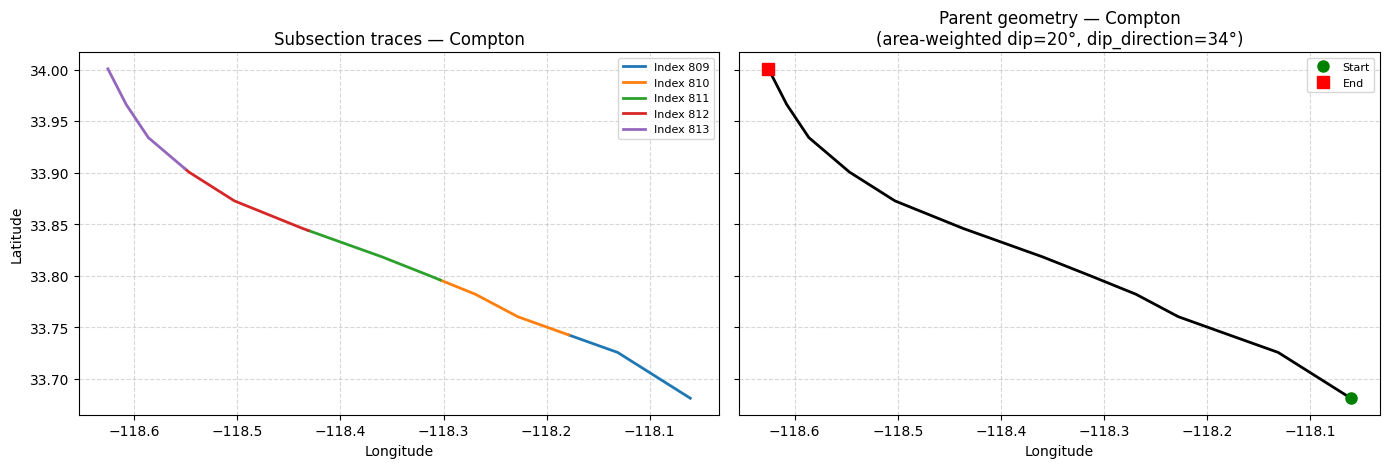

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Left: access the individual subsection traces
for idx, row in subs.iterrows():
    xs, ys = row["geometry"].xy
    # This is a shapely LineString object, so we can get the x and y coordinates directly
    ax1.plot(xs, ys, linewidth=2, label=f"Index {idx}")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title(f"Subsection traces — {flt.data.name}")
ax1.legend(fontsize=8)
ax1.set_aspect("equal")
ax1.grid(True, linestyle="--", alpha=0.5)

# Right: Parent geometry is readily available and oriented with dip on the right
trace = flt.data.geometry
lons, lats = trace.xy
ax2.plot(lons, lats, linewidth=2, color="black")
ax2.plot(lons[0], lats[0], "o", color="green", markersize=8, label="Start")
ax2.plot(lons[-1], lats[-1], "s", color="red", markersize=8, label="End")
ax2.set_xlabel("Longitude")
ax2.set_title(
    f"Parent geometry — {flt.data.name}\n"
    f"(area-weighted dip={dip:.0f}°, dip_direction={dip_direction:.0f}°)"
)
ax2.legend(fontsize=8)
ax2.set_aspect("equal")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Footprint (`data.geometry_3d`)

The 3D counterpart to `geometry`: the child subsection surfaces are stitched into a single
`PolygonZ`. This provides the parent fault footprint in map view.

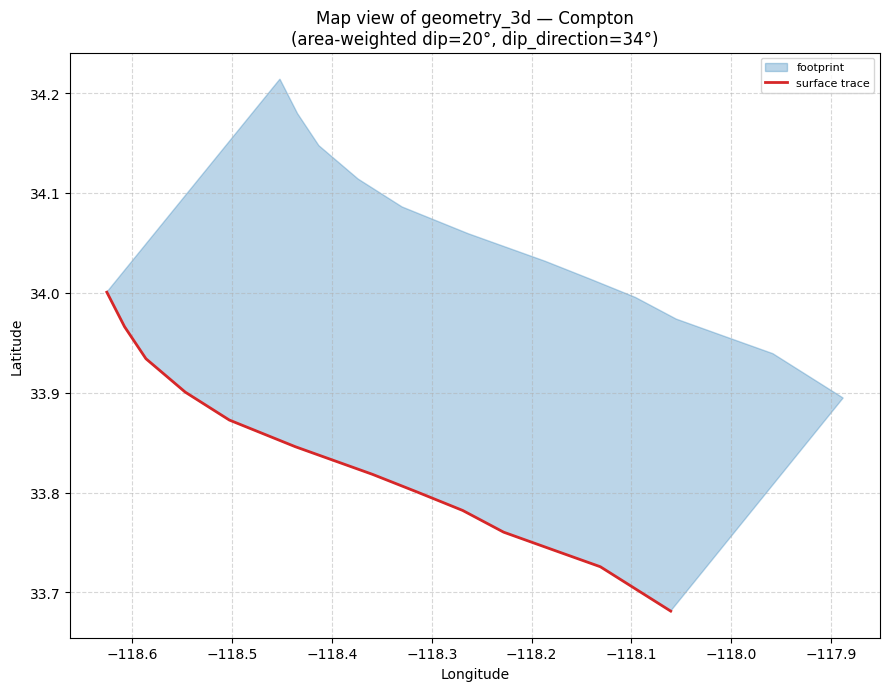

In [40]:
footprint = flt.data.geometry_3d
fx, fy = footprint.exterior.xy
tx, ty = flt.data.geometry.xy

fig, ax = plt.subplots(figsize=(9, 7))
ax.fill(fx, fy, alpha=0.3, color="tab:blue", label="footprint")
ax.plot(tx, ty, color="tab:red", linewidth=2, label="surface trace")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Map view of geometry_3d — {flt.data.name}\n"
    f"(area-weighted dip={dip:.0f}°, dip_direction={dip_direction:.0f}°)"
)
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Constructing per-parent data summaries

Earthquake rupture forecasts (ERFs) are built at the subsection level. Parent-level summaries are 
easy to build from `ds.subsections`, so consumers can choose the aggregation that matches their 
workflow.

In [41]:
parent_dimensions = (
    ds.subsections.assign(length_meters=ds.subsections["length_km"] * 1000.0)
    .groupby("parent_id")
    .agg(
        parent_name=("parent_name", "first"),
        length_meters=("length_meters", "sum"),
        dip_degrees_min=("dip", "min"),
        dip_degrees_max=("dip", "max"),
        dip_degrees_mean=("dip", "mean"),
        upper_depth_km_min=("upper_depth_km", "min"),
        upper_depth_km_max=("upper_depth_km", "max"),
        upper_depth_km_mean=("upper_depth_km", "mean"),
        lower_depth_km_min=("lower_depth_km", "min"),
        lower_depth_km_max=("lower_depth_km", "max"),
        lower_depth_km_mean=("lower_depth_km", "mean"),
    )
    .reset_index()
)

parent_dimensions.head()

,parent_id,parent_name,length_meters,dip_degrees_min,dip_degrees_max,dip_degrees_mean,upper_depth_km_min,upper_depth_km_max,upper_depth_km_mean,lower_depth_km_min,lower_depth_km_max,lower_depth_km_mean
0,1,Airport Lake,47122.932031,50.0,50.0,50.0,0.0,0.0,0.0,13.0,13.0,13.0
1,2,Almanor,34542.069300,90.0,90.0,90.0,0.0,0.0,0.0,10.0,10.0,10.0
2,3,Anacapa - Dume,64887.004711,45.0,45.0,45.0,0.0,0.0,0.0,15.5,15.5,15.5
3,5,Anaheim,15721.571346,71.0,71.0,71.0,3.8,3.8,3.8,14.2,14.2,14.2
4,6,Ash Hill,49118.249711,90.0,90.0,90.0,0.0,0.0,0.0,13.0,13.0,13.0


## 4. ParentFaultRuptures

### participating_ruptures

GeoDataFrame of all ruptures involving any child subsection of this parent fault. The `
contributions` column lists `(parent_id, area_pct)` tuples for every parent each rupture touches, 
so you can see the relative contribution of this parent and other parents for every rupture.

In [42]:
rups = flt.ruptures.participating_ruptures
print(f"{len(rups)} ruptures")
print("Columns:", list(rups.columns))
rups.head()

7230 ruptures
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'geometry', 'length_km', 'area_km2', 'contributions']


,m,rate,depth,dip,width,rake,geometry,length_km,area_km2,contributions
1956,7.15,1.669645e-09,3.241,45.1,21.252,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",49.174780,1088.344469,"[(3, 43.56092257573472), (43, 36.1927840965310..."
1957,7.36,5.858259e-10,3.296,38.5,22.825,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",71.108453,1711.583027,"[(3, 27.69908814193388), (43, 23.0139091992105..."
1958,7.41,5.821115e-11,3.870,37.2,21.902,73.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",82.976216,1860.481866,"[(3, 25.482263500431234), (43, 21.172050696551..."
1960,7.45,1.333749e-11,4.359,36.0,21.115,75.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",94.840401,2009.335812,"[(3, 23.594507625457194), (43, 19.603600425759..."
1961,7.42,3.768216e-09,3.395,39.7,21.869,72.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",84.560123,1922.301928,"[(3, 24.662769386835574), (43, 20.491170408257..."


**Working with rakes.** parserf exposes each rupture's raw `rake` (which is provided by the ERF) 
but does not classify styles of faulting. Here's an example of how you can do that: classify each 
rupture's rake into a style, then compare a raw rupture count against a rate-weighted tally. The 
two can differ significantly in some cases; the counts reflect how the inversion enumerated 
ruptures, while rate-weighting generallly will better reflect the underlying forecast itself.

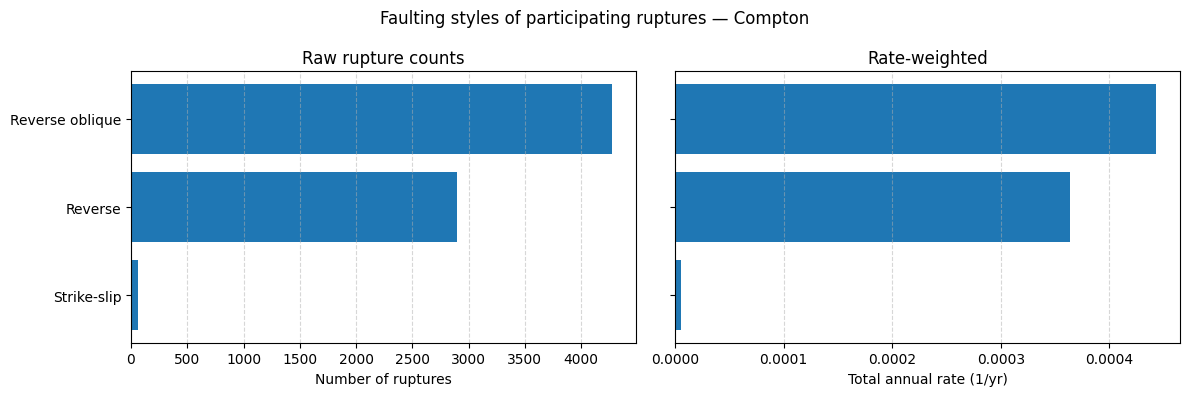

In [43]:
# Classify each rupture's rake into a style of faulting — your convention, your choice
def classify_rake(rake):
    rake = ((rake + 180) % 360) - 180  # normalize to [-180, 180)
    ranges = [
        ((-20, 20), "Strike-slip"),
        ((20, 70), "Reverse oblique"),
        ((70, 110), "Reverse"),
        ((110, 160), "Reverse oblique"),
        ((160, 180), "Strike-slip"),
        ((-180, -160), "Strike-slip"),
        ((-160, -110), "Normal oblique"),
        ((-110, -70), "Normal"),
        ((-70, -20), "Normal oblique"),
    ]
    for (low, high), label in ranges:
        if low <= rake < high:
            return label


styles = rups["rake"].apply(classify_rake)
counts = styles.value_counts()  # raw: one tally per rupture
rates = rups.groupby(styles)["rate"].sum()  # rate-weighted: sum of annual rates

order = counts.index  # same category order on both panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.barh(order, counts.loc[order])
ax1.set_xlabel("Number of ruptures")
ax1.set_title("Raw rupture counts")
ax1.invert_yaxis()
ax1.grid(axis="x", linestyle="--", alpha=0.5)

ax2.barh(order, rates.reindex(order, fill_value=0.0))
ax2.set_xlabel("Total annual rate (1/yr)")
ax2.set_title("Rate-weighted")
ax2.grid(axis="x", linestyle="--", alpha=0.5)

fig.suptitle(f"Faulting styles of participating ruptures — {flt.data.name}")
plt.tight_layout()
plt.show()

Each rupture's `contributions` lists `(parent_id, area_pct)` for every parent it touches. To
attribute a rupture's rate to individual faults:

- Explode `contributions` to one row per (rupture, parent) and split the tuples into
  `parent_id` / `area_pct`
- Keep this parent's rows and scale each rupture's rate by its area share (`rate × area_pct / 100`)

In [44]:
# Each rupture's `contributions` lists (parent_id, area_pct) for every parent it touches.
# Explode that column into one row per (rupture, parent), then split the tuples into columns:
exploded = rups.explode("contributions")
exploded[["parent_id", "area_pct"]] = pd.DataFrame(
    exploded["contributions"].tolist(), index=exploded.index
)

# Keep this parent's rows and attribute each rupture's rate to it by area:
this_parent = exploded[exploded["parent_id"] == flt.data.parent_id].copy()
this_parent["attributed_rate"] = (
    this_parent["rate"] * this_parent["area_pct"] / 100.0
)  # full rate × this parent's area share

print(f"{len(this_parent)} (rupture, {flt.data.name}) contributions")
this_parent[["m", "rate", "area_pct", "attributed_rate"]].head()

7230 (rupture, Compton) contributions


,m,rate,area_pct,attributed_rate
1956,7.15,1.669645e-09,36.192784,6.042910e-10
1957,7.36,5.858259e-10,23.013909,1.348214e-10
1958,7.41,5.821115e-11,21.172051,1.232449e-11
1960,7.45,1.333749e-11,19.603600,2.614629e-12
1961,7.42,3.768216e-09,20.491170,7.721515e-10


### cumulative_mfds

Cumulative magnitude frequency distributions for each child subsection.

In [45]:
mfds = flt.ruptures.cumulative_mfds
subsection_indices = sorted(int(i) for i in mfds["index"].unique())
print(f"Total rows: {len(mfds)}")
print(f"Subsection indices: {subsection_indices}")
mfds.head()

Total rows: 495
Subsection indices: [809, 810, 811, 812, 813]


,index,magnitude,cumulative_rate
0,809,6.98,0.000552
1,809,7.05,0.000499
2,809,7.07,0.000499
3,809,7.09,0.000499
4,809,7.11,0.000469


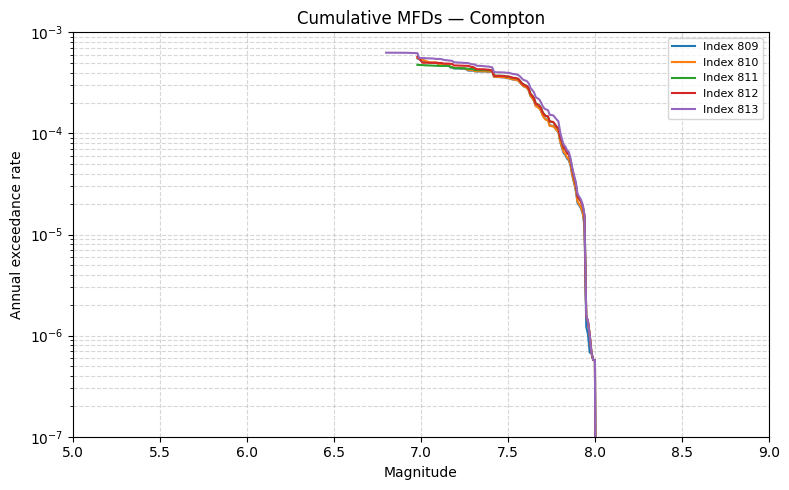

In [46]:
# Plot the cumulative MFDs for each subsection in the parent fault
fig, ax = plt.subplots(figsize=(8, 5))
for idx, group in mfds.groupby("index"):
    ax.semilogy(group["magnitude"], group["cumulative_rate"], linewidth=1.5, label=f"Index {idx}")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Annual exceedance rate")
ax.set_title(f"Cumulative MFDs \u2014 {flt.data.name}")
ax.set(xlim=(5, 9), ylim=(1e-7, 1e-3))
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Direct Instantiation

`ParentFaultData` and `ParentFaultRuptures` can be used standalone. They take
`parent_id` (an integer) rather than `name`.

In [47]:
pid = ds.get_parent_fault_id(name="Compton")

data = ParentFaultData(ds, parent_id=pid)
print("Name:", data.name)
print("Subsections:", len(data.subsections))

Name: Compton
Subsections: 5


In [48]:
ruptures = ParentFaultRuptures(ds, parent_id=pid)
print("Cumulative MFD rows:", len(ruptures.cumulative_mfds))

Cumulative MFD rows: 495
